# Machine Learning e Data Science com Python de A à Z - IA Expert Academy

## Dados desbalanceados

### Preparação dos dados

Dados desbalanceados

Quantidade muito grande de uma classe e poucos registros de outra classe


conda Udemy

In [1]:
import pandas as pd
import numpy as np
print(pd.__version__)
print(np.__version__) # antes estava 1.26.4, atualizado para 2.3.4

2.3.3
2.3.4


In [2]:
#!pip install numpy
#!pip install --force-reinstall "numpy>=2.0"
#https://www.kaggle.com/code/rafjaa/resampling-strategies-for-imbalanced-datasets

In [3]:
base_census = pd.read_csv('census.csv')
base_census.tail()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


previsão da renda da pessoa (income), se ganha mais do que 50mil ou menos por ano

In [4]:
np.unique(base_census['income'], return_counts = True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

dados desbalanceados, <=50K maior que o >50K 

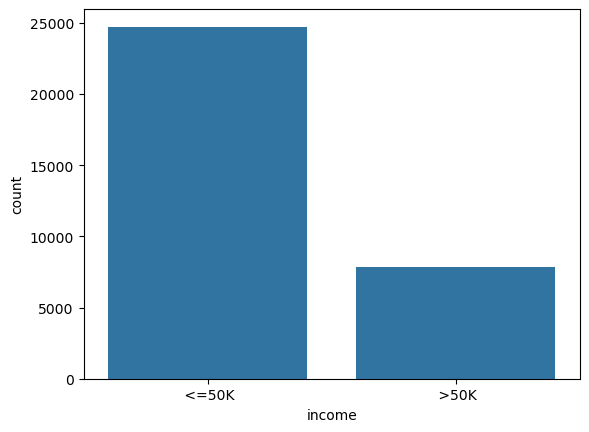

In [5]:
import seaborn as sns
sns.countplot(x = base_census['income']);

In [6]:
print(f' colunas para a base de previsão : {list(base_census.columns[0:14])}')

 colunas para a base de previsão : ['age', 'workclass', 'final-weight', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loos', 'hour-per-week', 'native-country']


In [7]:

# criar o atributo previsores do census
X_census = base_census.iloc[:, 0:14].values
X_census # convertendo para o numpy array

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      shape=(32561, 14), dtype=object)

In [8]:
# previsão: income, objetivo para a verificar à frente.

In [9]:
y_census = base_census.iloc[:, 14].values
y_census[:200]

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' >50K', ' >50K', ' >50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K', ' <=50K',
       ' <=50K', ' >50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K

### vamos converter 

### atributos categóricos (string ou palavras) será alterado para códigos em números (ou atributos numéricos), para se trabalhar, usando o LabelEncoder

In [10]:
from sklearn.preprocessing import LabelEncoder
label_encoder_workclass = LabelEncoder()
label_encoder_education = LabelEncoder()
label_encoder_marital = LabelEncoder()
label_encoder_occupation = LabelEncoder()
label_encoder_relationship = LabelEncoder()
label_encoder_race = LabelEncoder()
label_encoder_sex = LabelEncoder()
label_encoder_country = LabelEncoder()

In [11]:
X_census[:,1] = label_encoder_workclass.fit_transform(X_census[:,1])
X_census[:,3] = label_encoder_education.fit_transform(X_census[:,3])
X_census[:,5] = label_encoder_marital.fit_transform(X_census[:,5])
X_census[:,6] = label_encoder_occupation.fit_transform(X_census[:,6])
X_census[:,7] = label_encoder_relationship.fit_transform(X_census[:,7])
X_census[:,8] = label_encoder_race.fit_transform(X_census[:,8])
X_census[:,9] = label_encoder_sex.fit_transform(X_census[:,9])
X_census[:,13] = label_encoder_country.fit_transform(X_census[:,13])

In [12]:
X_census

array([[39, 7, 77516, ..., 0, 40, 39],
       [50, 6, 83311, ..., 0, 13, 39],
       [38, 4, 215646, ..., 0, 40, 39],
       ...,
       [58, 4, 151910, ..., 0, 40, 39],
       [22, 4, 201490, ..., 0, 20, 39],
       [52, 5, 287927, ..., 0, 40, 39]], shape=(32561, 14), dtype=object)

recall maior para o <=50K 96%

já o recall >50K é de 61% 

problema ainda no maior do que 50K



In [13]:
# apagando os dois registros, com as duas superfícies melhores.

### Sobreamostragem com SMOTE

In [15]:
np.unique(base_census['income'], return_counts = True)
# para a classe das pessoas que ganham mais de 50k dolares

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

In [16]:
X_census.shape

(32561, 14)

# correto é X_census e y_census

In [18]:
smote = SMOTE(sampling_strategy='minority') # balancear na classe minoritária  
X_over, y_over = smote.fit_resample(X_census, y_census) #Atualizado 20/05/2022

In [19]:
X_over.shape # é notado que foram criado novos registros

(49440, 14)

In [20]:
np.unique(y_census, return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

In [21]:
np.unique(y_over, return_counts=True) # mesmo valores do eixo y do <=50K e >50K

(array([' <=50K', ' >50K'], dtype=object), array([24720, 24720]))

fizemos a relação de novos registros onde há menores dados


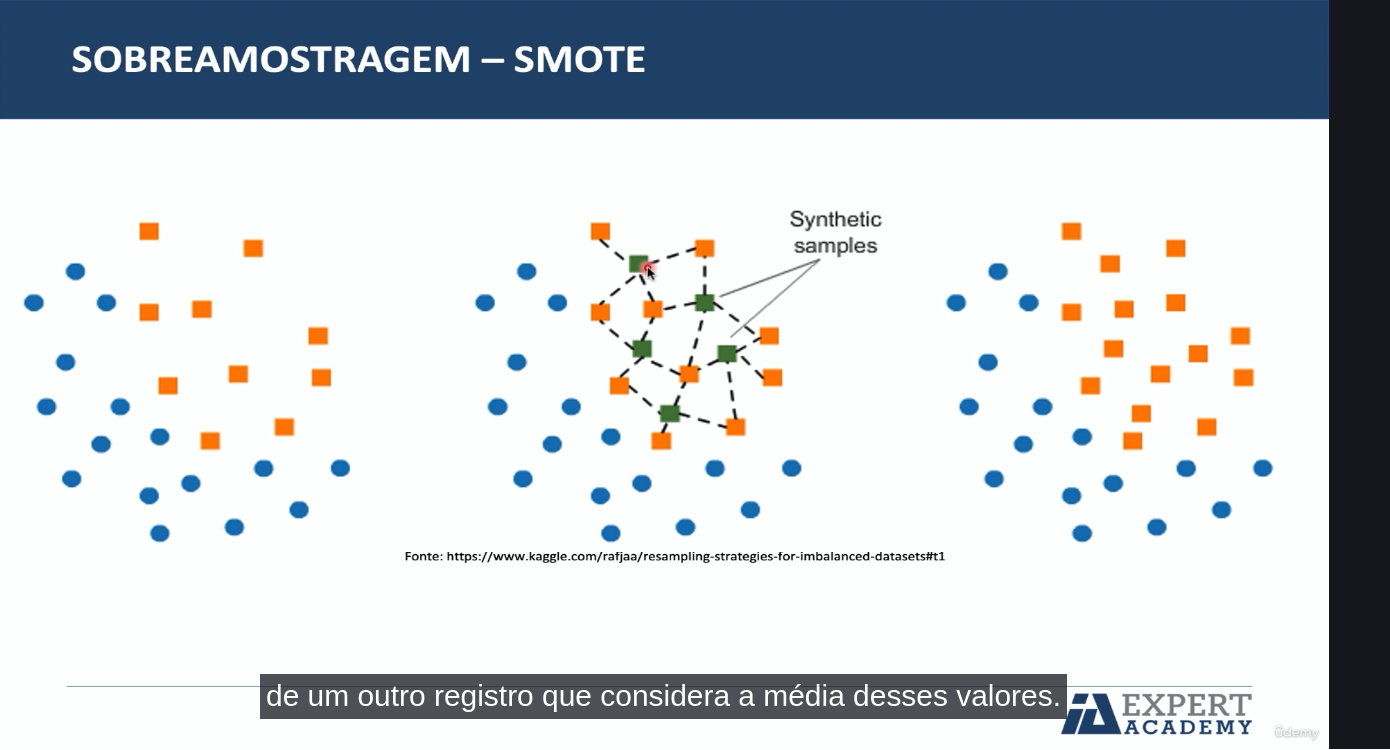

média de valores, com o cálculo das distâncias

In [24]:
# processo de escalonamento, com falha na memória
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
onehotencorder = ColumnTransformer(transformers=[("OneHot", OneHotEncoder(), [1,3,5,6,7,8,9,13])],remainder='passthrough')
# Mantenha a matriz esparsa, removendo o .toarray()
X_census_3 = onehotencorder.fit_transform(X_over)
#X_census_3 = onehotencorder.fit_transform(X_over).toarray()
X_census_3

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 602806 stored elements and shape (49440, 57626)>

In [25]:
from sklearn.model_selection import train_test_split
X_census_treinamento_over, X_census_teste_over, y_census_treinamento_over, y_census_teste_over = train_test_split(X_over, y_over, test_size=0.15, random_state=0)
X_census_treinamento_over.shape, X_census_teste_over.shape # treino e teste

((42024, 14), (7416, 14))

In [26]:
from sklearn.ensemble import RandomForestClassifier
random_forest_census = RandomForestClassifier(criterion = 'entropy', min_samples_leaf =  1, min_samples_split = 5, n_estimators = 100)
random_forest_census.fit(X_census_treinamento_over, y_census_treinamento_over)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [27]:
random_forest_census.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'entropy',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [29]:
from sklearn.metrics import accuracy_score, classification_report
previsoes = random_forest_census.predict(X_census_teste_over)
accuracy_score(y_census_teste_over, previsoes)


0.9095199568500539

In [30]:
acuracia = accuracy_score(y_census_teste_over, previsoes)
print(f'processo {acuracia*100:.2f} %') #aumentou a acurácia e a precisão. 

processo 90.95 %


In [31]:
print(classification_report(y_census_teste_over, previsoes))

              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      3722
        >50K       0.93      0.89      0.91      3694

    accuracy                           0.91      7416
   macro avg       0.91      0.91      0.91      7416
weighted avg       0.91      0.91      0.91      7416



In [33]:
# o recall do >50K aumentou, o que é muito bom. Além do recall <=50K